# Random Forest for Just-In-Time Bug Prediction

## Objective

Train and evaluate a Random Forest classifier for predicting
bug-inducing commits and compare its performance against
the Logistic Regression baseline.

Expected Outcome:
- Improved Precision
- Improved F1 Score
- Better handling of nonlinear relationships

In [4]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    roc_curve
)

from imblearn.over_sampling import SMOTE

import joblib

pd.set_option('display.max_columns', None)

In [6]:
df = pd.read_csv(
    "/content/drive/MyDrive/JIT_bug_prediction/data/processed_data.csv"
)

df.head()

,author_date,la,ld,nf,nd,ns,ent,ndev,age,nuc,aexp,arexp,asexp,buggy
0,1063292086,58,0,1,1,1,0.0,1.0,0.0,1.0,10,10.0,6.0,0
1,1063292137,78,0,1,1,1,0.0,0.0,0.0,0.0,21,21.0,1.0,0
2,1063292285,2,3,1,1,1,0.0,2.0,0.0,2.0,11,11.0,7.0,0
3,1063292362,2,0,1,1,1,0.0,2.0,0.0,3.0,12,12.0,8.0,0
4,1063292625,33,0,1,1,1,0.0,1.0,0.0,1.0,13,13.0,9.0,0


In [7]:
print(df.shape)

df.info()

(106674, 14)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 106674 entries, 0 to 106673
Data columns (total 14 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   author_date  106674 non-null  int64  
 1   la           106674 non-null  int64  
 2   ld           106674 non-null  int64  
 3   nf           106674 non-null  int64  
 4   nd           106674 non-null  int64  
 5   ns           106674 non-null  int64  
 6   ent          106674 non-null  float64
 7   ndev         106674 non-null  float64
 8   age          106674 non-null  float64
 9   nuc          106674 non-null  float64
 10  aexp         106674 non-null  int64  
 11  arexp        106674 non-null  float64
 12  asexp        106674 non-null  float64
 13  buggy        106674 non-null  int64  
dtypes: float64(6), int64(8)
memory usage: 11.4 MB


In [8]:
features = [
    'la',
    'ld',
    'nf',
    'nd',
    'ns',
    'ent',
    'ndev',
    'age',
    'nuc',
    'aexp',
    'arexp',
    'asexp'
]

target = 'buggy'

In [9]:
df = df.sort_values('author_date')

split_index = int(len(df) * 0.8)

train_df = df.iloc[:split_index]
test_df = df.iloc[split_index:]

X_train = train_df[features]
y_train = train_df[target]

X_test = test_df[features]
y_test = test_df[target]

In [10]:
smote = SMOTE(
    random_state=42
)

X_train_smote, y_train_smote = smote.fit_resample(
    X_train,
    y_train
)

print(X_train_smote.shape)
print(y_train_smote.value_counts())

(121178, 12)
buggy
0    60589
1    60589
Name: count, dtype: int64


In [11]:
rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    random_state=42,
    n_jobs=-1
)

rf.fit(
    X_train_smote,
    y_train_smote
)

RandomForestClassifier(max_depth=10, n_estimators=200, n_jobs=-1,
                       random_state=42)

In [12]:
rf_pred = rf.predict(X_test)

rf_prob = rf.predict_proba(X_test)[:,1]

In [13]:
accuracy = accuracy_score(y_test, rf_pred)

precision = precision_score(y_test, rf_pred)

recall = recall_score(y_test, rf_pred)

f1 = f1_score(y_test, rf_pred)

auc = roc_auc_score(y_test, rf_prob)

results = pd.DataFrame({
    'Metric':[
        'Accuracy',
        'Precision',
        'Recall',
        'F1 Score',
        'ROC AUC'
    ],
    'Value':[
        accuracy,
        precision,
        recall,
        f1,
        auc
    ]
})

results

,Metric,Value
0,Accuracy,0.681837
1,Precision,0.315678
2,Recall,0.809688
3,F1 Score,0.454253
4,ROC AUC,0.808421


In [15]:
results.to_csv(
    "/content/drive/MyDrive/JIT_bug_prediction/outputs/tables/random_forest_metrics.csv",
    index=False
)

In [16]:
report = classification_report(
    y_test,
    rf_pred,
    output_dict=True
)

report_df = pd.DataFrame(report).transpose()

report_df

,precision,recall,f1-score,support
0,0.946391,0.656842,0.775470,17846.000000
1,0.315678,0.809688,0.454253,3489.000000
accuracy,0.681837,0.681837,0.681837,0.681837
macro avg,0.631034,0.733265,0.614861,21335.000000
weighted avg,0.843248,0.681837,0.722940,21335.000000


In [17]:
report_df.to_csv(
    "/content/drive/MyDrive/JIT_bug_prediction/outputs/tables/random_forest_classification_report.csv"
)

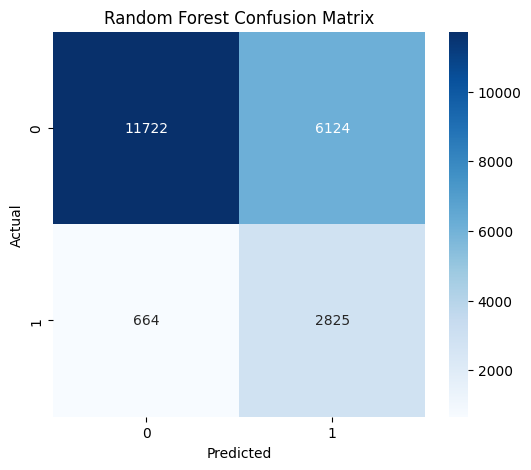

In [18]:
cm = confusion_matrix(
    y_test,
    rf_pred
)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title("Random Forest Confusion Matrix")

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.savefig(
    "/content/drive/MyDrive/JIT_bug_prediction/outputs/plots/random_forest_confusion_matrix.png"
)

plt.show()

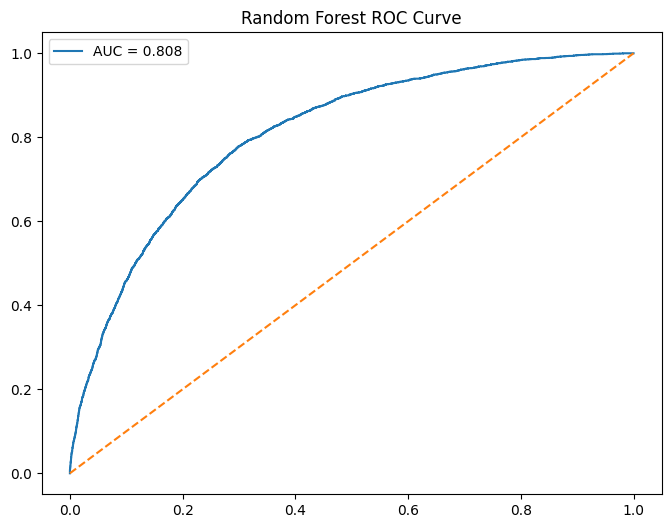

In [19]:
fpr, tpr, _ = roc_curve(
    y_test,
    rf_prob
)

plt.figure(figsize=(8,6))

plt.plot(
    fpr,
    tpr,
    label=f"AUC = {auc:.3f}"
)

plt.plot(
    [0,1],
    [0,1],
    '--'
)

plt.legend()

plt.title("Random Forest ROC Curve")

plt.savefig(
    "/content/drive/MyDrive/JIT_bug_prediction/outputs/plots/random_forest_roc_curve.png"
)

plt.show()

In [20]:
importance = pd.DataFrame({
    'Feature':features,
    'Importance':rf.feature_importances_
})

importance = importance.sort_values(
    'Importance',
    ascending=False
)

importance

,Feature,Importance
0,la,0.301872
5,ent,0.159059
2,nf,0.119935
7,age,0.104420
1,ld,0.082698
8,nuc,0.048719
6,ndev,0.047678
11,asexp,0.035152
9,aexp,0.029409
3,nd,0.028278


In [21]:
importance.to_csv(
    "/content/drive/MyDrive/JIT_bug_prediction/outputs/tables/random_forest_feature_importance.csv",
    index=False
)

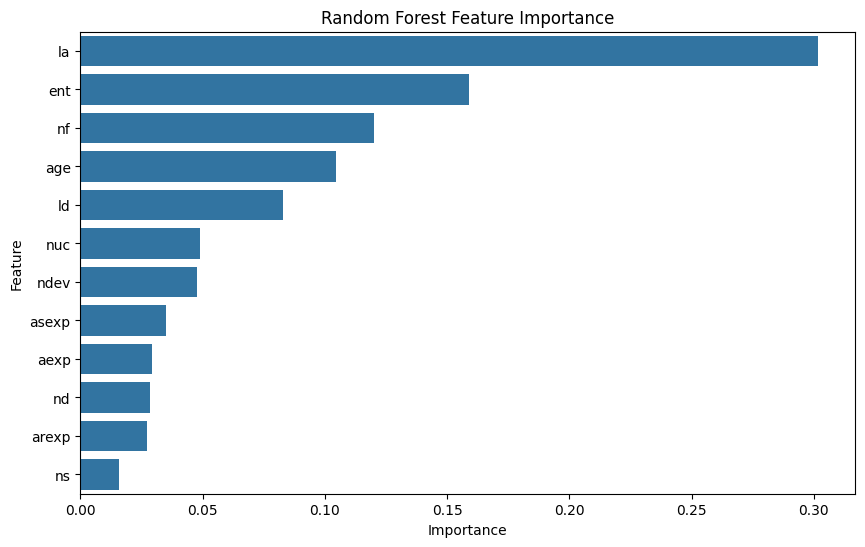

In [22]:
plt.figure(figsize=(10,6))

sns.barplot(
    data=importance,
    x='Importance',
    y='Feature'
)

plt.title(
    "Random Forest Feature Importance"
)

plt.savefig(
    "/content/drive/MyDrive/JIT_bug_prediction/outputs/plots/random_forest_feature_importance.png"
)

plt.show()

In [23]:
rf.score(X_train_smote, y_train_smote)

0.7838964168413408

In [25]:
import joblib

joblib.dump(
    rf,
    "/content/drive/MyDrive/JIT_bug_prediction/models/random_forest.pkl"
)

print("Random Forest model saved successfully.")

Random Forest model saved successfully.


In [26]:
comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Random Forest"
    ],
    "Accuracy": [
        0.692383,
        0.681837
    ],
    "Precision": [
        0.304552,
        0.315678
    ],
    "Recall": [
        0.686443,
        0.809688
    ],
    "F1 Score": [
        0.421915,
        0.454253
    ],
    "ROC AUC": [
        0.7612,
        0.8084
    ]
})

comparison

,Model,Accuracy,Precision,Recall,F1 Score,ROC AUC
0,Logistic Regression,0.692383,0.304552,0.686443,0.421915,0.7612
1,Random Forest,0.681837,0.315678,0.809688,0.454253,0.8084


In [27]:
comparison.to_csv(
    "/content/drive/MyDrive/JIT_bug_prediction/outputs/tables/model_comparison.csv",
    index=False
)

# Findings

## Random Forest Performance

| Metric | Value |
|----------|----------|
| Accuracy | 68.18% |
| Precision | 31.57% |
| Recall | 80.97% |
| F1 Score | 45.43% |
| ROC-AUC | 0.8084 |

---

## Interpretation

Random Forest was trained using the same software change metrics
used in the Logistic Regression baseline.

The model achieved a Recall of 80.97%, indicating that it successfully
identified a large majority of bug-inducing commits.

Compared to Logistic Regression, Random Forest demonstrated
improvements in Recall, F1 Score, and ROC-AUC, suggesting that
ensemble learning methods are more effective at capturing
non-linear relationships within software metrics.

---

## Feature Importance Analysis

The most influential predictors were:

1. LA (Lines Added)
2. ENT (Entropy)
3. NF (Number of Modified Files)
4. AGE (Average File Age)
5. LD (Lines Deleted)

These findings align with prior software engineering studies,
which suggest that larger and more scattered code changes
have a higher probability of introducing defects.

---

## Comparison with Logistic Regression

| Metric | Logistic Regression | Random Forest |
|----------|----------|----------|
| Precision | 30.46% | 31.57% |
| Recall | 68.64% | 80.97% |
| F1 Score | 42.19% | 45.43% |
| ROC-AUC | 0.7612 | 0.8084 |

Random Forest outperformed Logistic Regression on all major
classification metrics except accuracy.

The increase in Recall and ROC-AUC indicates that Random Forest
provides stronger predictive performance for identifying
defect-inducing commits.

---

## Conclusion

Random Forest serves as a stronger model than Logistic Regression
for Just-In-Time bug prediction.

The model demonstrates improved defect detection capability and
better discrimination between buggy and non-buggy commits.

Future work will investigate XGBoost to determine whether further
performance gains can be achieved.